In [15]:
%pip -q install nvidia-ml-py
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
Tesla T4


In [16]:
import torch
from torch import nn


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Conv2d(32, 64, 5, padding=2, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, 1, bias=False),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(256, 100, bias=False),
        )

    def forward(self, x):
        return self.head(self.features(x))


In [17]:
import numpy as np


PARAMETERS = 1_039_968
THETA_REPORT = {
    "fp32_flops_per_s": 8.1e12,
    "memory_bytes_per_s": 320e9,
    "mfu": 0.5,
    "launch_s": 0.0,
}
THETA_ENERGY_REPORT = {"latency": THETA_REPORT, "power_w": 70.0}


def _result(value):
    return float(value) if np.ndim(value) == 0 else value


def flops(image_size, batch):
    s, b = np.broadcast_arrays(image_size, batch)
    return _result(b * (17_714 * s**2 + 313_344))


def memory(image_size, batch):
    s, b = np.broadcast_arrays(image_size, batch)
    return _result(4 * PARAMETERS + 52 * b * s**2)


def bytes_moved(image_size, batch):
    s, b = np.broadcast_arrays(image_size, batch)
    return _result(4 * (PARAMETERS + b * (91 * s**2 + 2_148)))


def latency(image_size, batch, theta):
    f = flops(image_size, batch)
    d = bytes_moved(image_size, batch)
    compute_s = f / (theta["fp32_flops_per_s"] * theta["mfu"])
    memory_s = d / theta["memory_bytes_per_s"]
    return _result(theta["launch_s"] + compute_s + memory_s)


def energy(image_size, batch, theta_energy):
    t = latency(image_size, batch, theta_energy["latency"])
    return _result(theta_energy["power_w"] * t)


In [18]:
import gc
import json
import platform
import random
import threading
import time
from pathlib import Path

import pynvml
import torch
import pandas as pd
from torch.profiler import ProfilerActivity, profile


RESULTS = Path("/content/hw1_results")
SEED = 19
BASE_S = [32, 64, 128, 224, 256, 384, 512]
BASE_B = [1, 2, 4, 8, 16, 32, 64, 128, 256]


def grid():
    rng = random.Random(SEED)
    sizes = sorted(BASE_S + rng.sample(
        [s for s in range(32, 513, 16) if s not in BASE_S], 4
    ))
    batches = sorted(BASE_B + rng.sample(
        [b for b in range(1, 257) if b not in BASE_B], 3
    ))
    pairs = [(s, b) for s in sizes for b in batches]
    validation = set(rng.sample(pairs, round(len(pairs) * 0.2)))
    return pairs, validation


def gpu_energy_j(handle, model, x, minimum_seconds=0.75):
    torch.cuda.synchronize()
    try:
        before_mj = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
    except pynvml.NVMLError:
        before_mj = None

    samples = []
    stop = threading.Event()
    if before_mj is None:
        def sample_power():
            while not stop.is_set():
                samples.append(pynvml.nvmlDeviceGetPowerUsage(handle) / 1000)
                stop.wait(0.02)

        thread = threading.Thread(target=sample_power, daemon=True)
        thread.start()

    start = time.perf_counter()
    count = 0
    try:
        while time.perf_counter() - start < minimum_seconds or count < 2:
            model(x)
            torch.cuda.synchronize()
            count += 1
        elapsed = time.perf_counter() - start
        if before_mj is not None:
            joules = (pynvml.nvmlDeviceGetTotalEnergyConsumption(handle) - before_mj) / 1000
        else:
            stop.set()
            thread.join()
            joules = sum(samples) / len(samples) * elapsed
        return joules / count
    finally:
        if before_mj is None:
            stop.set()
            thread.join()


@torch.inference_mode()
def measure_one(model, s, b, handle):
    x = torch.randn(b, 3, s, s, device="cuda", dtype=torch.float32)
    for _ in range(3):
        model(x)
    torch.cuda.synchronize()

    torch.cuda.reset_peak_memory_stats()
    model(x)
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()

    timings = []
    for _ in range(10):
        torch.cuda.synchronize()
        start = time.perf_counter()
        model(x)
        torch.cuda.synchronize()
        timings.append(time.perf_counter() - start)
    timings.sort()
    median = (timings[4] + timings[5]) / 2
    joules = gpu_energy_j(handle, model, x)
    with profile(activities=[ProfilerActivity.CPU], with_flops=True) as prof:
        model(x)
        torch.cuda.synchronize()
    profiled_flops = sum(event.flops or 0 for event in prof.key_averages())
    return median, peak, joules, profiled_flops



def run_measurements():
    RESULTS.mkdir(parents=True, exist_ok=True)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cuda.matmul.allow_tf32 = False
    model = SmallCNN().cuda().eval()
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())

    environment = {
        "gpu": torch.cuda.get_device_name(),
        "total_memory_bytes": torch.cuda.get_device_properties(0).total_memory,
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "benchmark": False,
        "cudnn_allow_tf32": False,
        "matmul_allow_tf32": False,
        "seed": SEED,
    }
    (RESULTS / "environment.json").write_text(json.dumps(environment, indent=2) + "\n")

    pairs, validation = grid()
    rows = []
    try:
        for s, b in pairs:
            row = {"image_size": s, "batch": b,
                   "is_validation": int((s, b) in validation)}
            try:
                latency_s, memory_bytes, energy_j, profiled_flops = measure_one(model, s, b, handle)
                row.update(latency_s=latency_s, memory_bytes=memory_bytes,
                           energy_j=energy_j, profiled_flops=profiled_flops, status="ok")
            except torch.cuda.OutOfMemoryError:
                row.update(latency_s="", memory_bytes="", energy_j="",
                           profiled_flops="", status="OOM")
                gc.collect()
                torch.cuda.empty_cache()
            rows.append(row)
            pd.DataFrame(rows).to_csv(RESULTS / "measurements.csv", index=False)
            print(f"S={s}, B={b}: {row['status']}", flush=True)
    finally:
        pynvml.nvmlShutdown()
    return rows


In [19]:
measurements = run_measurements()

S=32, B=1: ok
S=32, B=2: ok
S=32, B=4: ok
S=32, B=8: ok
S=32, B=16: ok
S=32, B=32: ok
S=32, B=58: ok
S=32, B=64: ok
S=32, B=108: ok
S=32, B=128: ok
S=32, B=139: ok
S=32, B=256: ok
S=64, B=1: ok
S=64, B=2: ok
S=64, B=4: ok
S=64, B=8: ok
S=64, B=16: ok
S=64, B=32: ok
S=64, B=58: ok
S=64, B=64: ok
S=64, B=108: ok
S=64, B=128: ok
S=64, B=139: ok
S=64, B=256: ok
S=80, B=1: ok
S=80, B=2: ok
S=80, B=4: ok
S=80, B=8: ok
S=80, B=16: ok
S=80, B=32: ok
S=80, B=58: ok
S=80, B=64: ok
S=80, B=108: ok
S=80, B=128: ok
S=80, B=139: ok
S=80, B=256: ok
S=112, B=1: ok
S=112, B=2: ok
S=112, B=4: ok
S=112, B=8: ok
S=112, B=16: ok
S=112, B=32: ok
S=112, B=58: ok
S=112, B=64: ok
S=112, B=108: ok
S=112, B=128: ok
S=112, B=139: ok
S=112, B=256: ok
S=128, B=1: ok
S=128, B=2: ok
S=128, B=4: ok
S=128, B=8: ok
S=128, B=16: ok
S=128, B=32: ok
S=128, B=58: ok
S=128, B=64: ok
S=128, B=108: ok
S=128, B=128: ok
S=128, B=139: ok
S=128, B=256: ok
S=224, B=1: ok
S=224, B=2: ok
S=224, B=4: ok
S=224, B=8: ok
S=224, B=16: ok


In [20]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def fit_launch_overhead(rows):
    s = np.array([int(r["image_size"]) for r in rows])
    b = np.array([int(r["batch"]) for r in rows])
    measured = np.array([float(r["latency_s"]) for r in rows])
    report_prediction = latency(s, b, THETA_REPORT)
    return max(0.0, float(np.mean(measured - report_prediction)))


def error_summary(rows, theta_latency, theta_energy):
    summary = {}
    for label, subset in (
        ("calibration", [r for r in rows if r["status"] == "ok" and r["is_validation"] == 0]),
        ("validation", [r for r in rows if r["status"] == "ok" and r["is_validation"] == 1]),
    ):
        s = np.array([int(r["image_size"]) for r in subset])
        b = np.array([int(r["batch"]) for r in subset])
        metrics = {
            "flops": (flops(s, b), np.array([float(r["profiled_flops"]) for r in subset])),
            "latency": (latency(s, b, theta_latency), np.array([float(r["latency_s"]) for r in subset])),
            "memory": (memory(s, b), np.array([float(r["memory_bytes"]) for r in subset])),
            "energy": (energy(s, b, theta_energy), np.array([float(r["energy_j"]) for r in subset])),
        }
        summary[label] = {name + "_median_ape": float(np.median(abs(p - y) / y))
                          for name, (p, y) in metrics.items()}
        summary[label]["count"] = len(subset)
    summary["oom_count"] = sum(r["status"] == "OOM" for r in rows)
    total_gpu_bytes = torch.cuda.get_device_properties(0).total_memory
    summary["oom_comparison"] = [
        {"image_size": int(r["image_size"]), "batch": int(r["batch"]),
         "predicted_peak_bytes": memory(int(r["image_size"]), int(r["batch"])),
         "gpu_capacity_bytes": total_gpu_bytes}
        for r in rows if r["status"] == "OOM"
    ]
    return summary


def plot_metric(rows, name, function, measured_field, unit, scale=1):
    figures = RESULTS / "figures"
    figures.mkdir(exist_ok=True)
    ss = np.linspace(32, 512, 60)
    bb = np.linspace(1, 256, 60)
    s_grid, b_grid = np.meshgrid(ss, bb)
    z = function(s_grid, b_grid) / scale

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(projection="3d")
    ax.plot_surface(s_grid, b_grid, z, alpha=0.4, cmap="viridis")
    for flag, marker, color, label in (
        ("0", "o", "black", "замеры калибровки"),
        ("1", "^", "red", "замеры валидации"),
    ):
        selected = [r for r in rows if r["status"] == "ok" and r["is_validation"] == int(flag)]
        ax.scatter(
            [int(r["image_size"]) for r in selected],
            [int(r["batch"]) for r in selected],
            [float(r[measured_field]) / scale for r in selected],
            marker=marker, color=color, s=12, label=label,
        )
    ax.set_xlabel("S")
    ax.set_ylabel("B")
    ax.set_zlabel(f"{name} ({unit})")
    ax.set_title(f"{name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figures / f"{name.lower().replace(' ', '_')}.png", dpi=180)
    plt.show()
    plt.close(fig)


def run_analysis(rows):
    train = [r for r in rows if r["status"] == "ok" and r["is_validation"] == 0]
    fitted_latency = dict(THETA_REPORT)
    fitted_latency["launch_s"] = fit_launch_overhead(train)
    fitted_energy = {"latency": fitted_latency, "power_w": 70.0}
    theta = {
        "report": {"latency": THETA_REPORT, "energy": THETA_ENERGY_REPORT},
        "calibrated": {"latency": fitted_latency, "energy": fitted_energy},
        "calibrated_parameter": "launch_s only; report mfu, bandwidth and 70 W stay fixed",
    }
    (RESULTS / "theta.json").write_text(json.dumps(theta, indent=2) + "\n")
    summary = {
        "report": error_summary(rows, THETA_REPORT, THETA_ENERGY_REPORT),
        "calibrated": error_summary(rows, fitted_latency, fitted_energy),
    }
    (RESULTS / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")

    plot_metric(rows, "FLOPs", flops, "profiled_flops", "GFLOPs", 1e9)
    plot_metric(rows, "Память", memory, "memory_bytes", "MiB", 2**20)
    plot_metric(rows, "Задержка", lambda s, b: latency(s, b, THETA_REPORT), "latency_s", "ms", 1e-3)
    plot_metric(rows, "Энергия", lambda s, b: energy(s, b, THETA_ENERGY_REPORT), "energy_j", "J")
    plot_metric(rows, "Откалиброванная задержка", lambda s, b: latency(s, b, fitted_latency), "latency_s", "ms", 1e-3)
    plot_metric(rows, "Откалиброванная энергия", lambda s, b: energy(s, b, fitted_energy), "energy_j", "J")
    print(json.dumps(summary, indent=2))
    return theta, summary


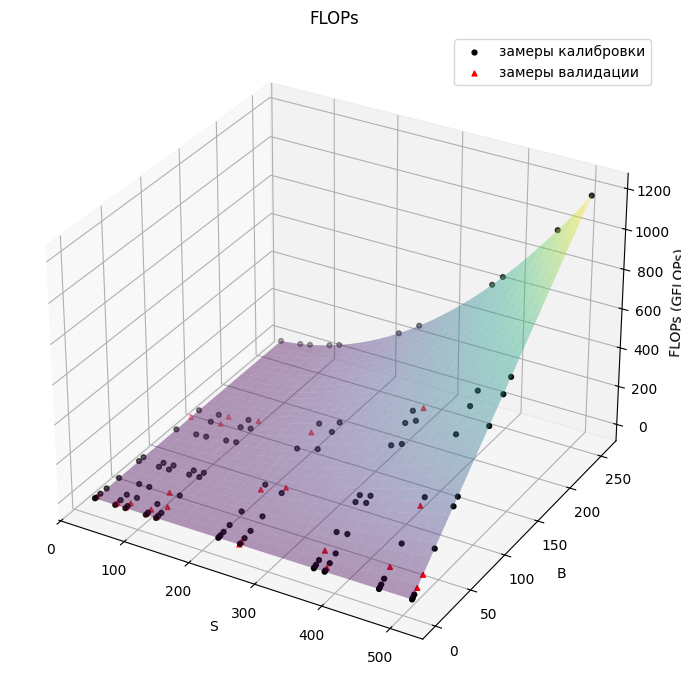

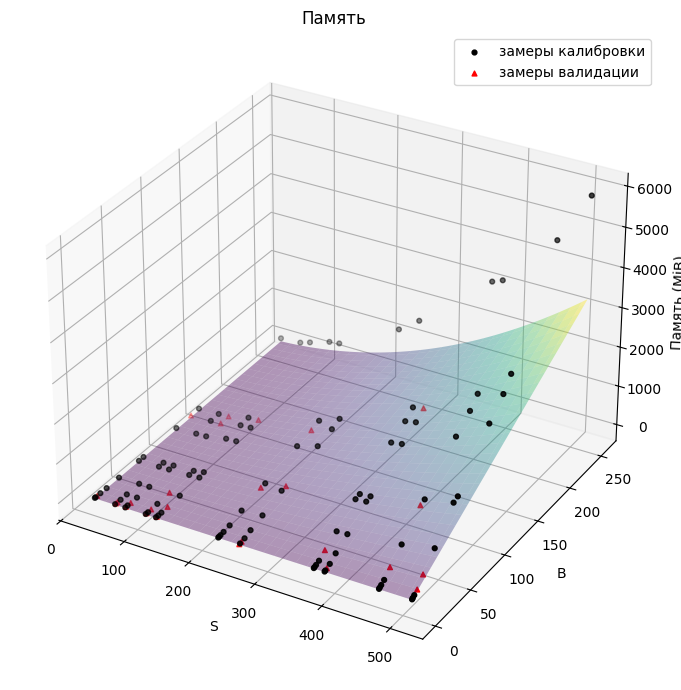

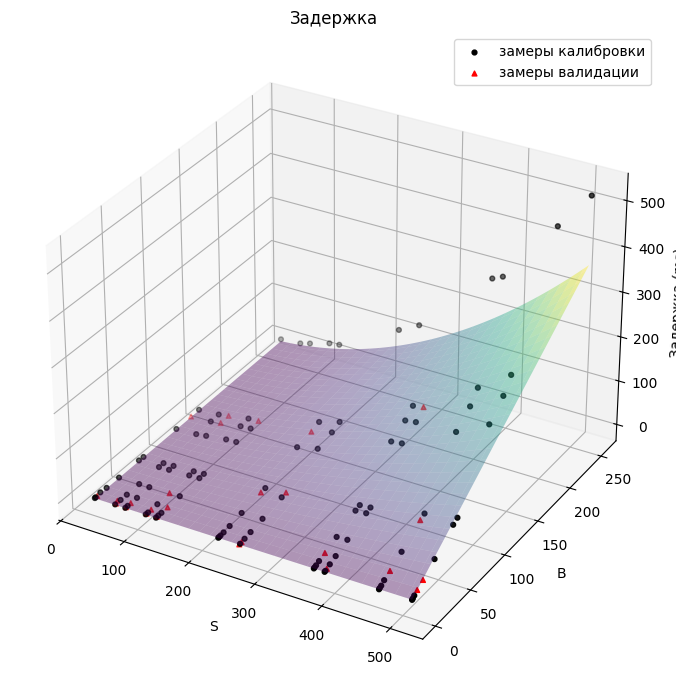

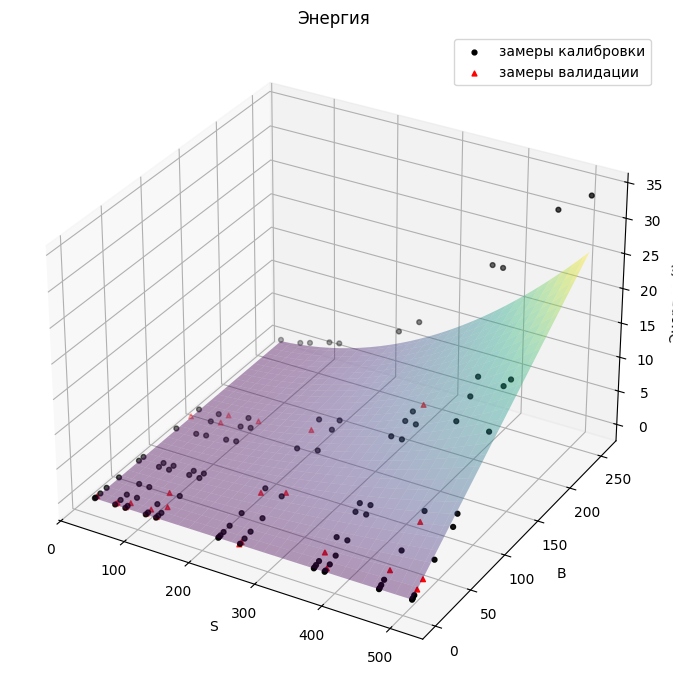

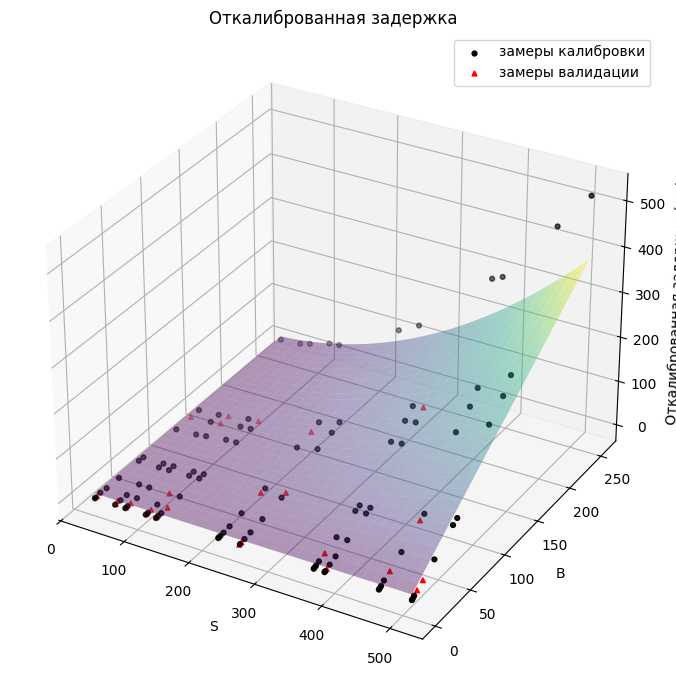

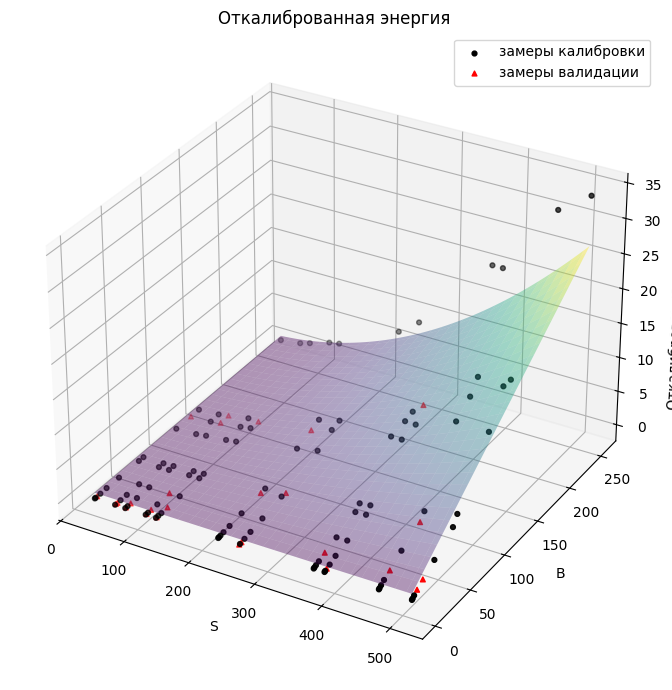

{
  "report": {
    "calibration": {
      "flops_median_ape": 0.00011287799731396439,
      "latency_median_ape": 0.28370247974083584,
      "memory_median_ape": 0.4770164280304895,
      "energy_median_ape": 0.2412324206393655,
      "count": 106
    },
    "validation": {
      "flops_median_ape": 0.00011279600138175102,
      "latency_median_ape": 0.3045455043499157,
      "memory_median_ape": 0.4831061785576773,
      "energy_median_ape": 0.2890592790190833,
      "count": 26
    },
    "oom_count": 0,
    "oom_comparison": []
  },
  "calibrated": {
    "calibration": {
      "flops_median_ape": 0.00011287799731396439,
      "latency_median_ape": 2.057393277758771,
      "memory_median_ape": 0.4770164280304895,
      "energy_median_ape": 2.0835121747725793,
      "count": 106
    },
    "validation": {
      "flops_median_ape": 0.00011279600138175102,
      "latency_median_ape": 2.833798391609246,
      "memory_median_ape": 0.4831061785576773,
      "energy_median_ape": 3.79925755

In [21]:
theta, summary = run_analysis(measurements)